In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from word2number import w2n


In [6]:
df=pd.read_csv("area.csv")
df


,Area,Price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


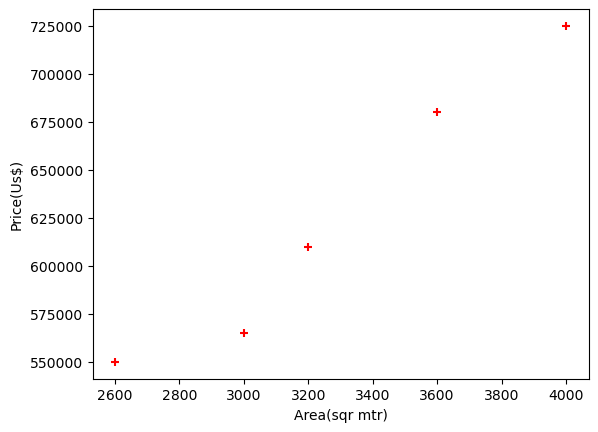

In [7]:
%matplotlib inline
plt.xlabel('Area(sqr mtr)')
plt.ylabel('Price(Us$)')
plt.scatter(df.Area,df.Price,color='red',marker="+")


In [8]:
reg=linear_model.LinearRegression()
reg.fit(df[['Area']],df.Price)

LinearRegression()

In [9]:
reg.predict([[5000]])

C:\Anaconda\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])

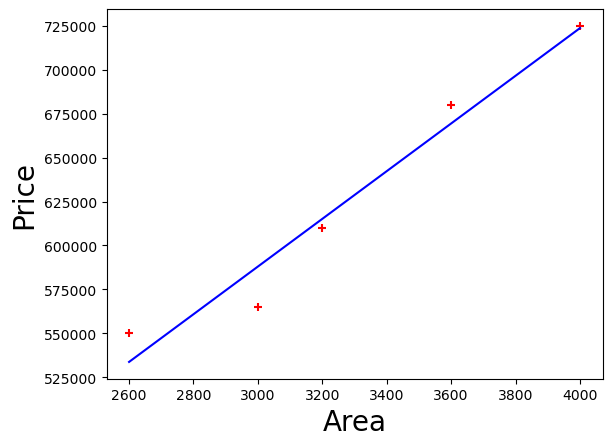

In [10]:
%matplotlib inline
plt.xlabel('Area',fontsize=20)
plt.ylabel('Price',fontsize=20)
plt.scatter(df.Area,df.Price,color='red',marker="+")
plt.plot(df.Area,reg.predict(df[['Area']]),color='blue')

In [11]:
reg.coef_

array([135.78767123])

In [12]:
reg.intercept_

180616.43835616432

This is predicted using y=m*x+c



In [13]:
d=pd.read_csv("areas.csv")
d

,Area
0,1000
1,1500
2,2300
3,3540
4,4120
5,4560
6,5490
7,3460
8,4750
9,2300


In [14]:
p=reg.predict(d)



In [15]:
d["Prices"]=p

In [16]:
d.to_csv("prediction.csv",index=False)


### homework session-1  

In [17]:
cd=pd.read_csv("canada.csv")
cd.head(3)


,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484


#### what is the expected per capita income of canada in year 2020?


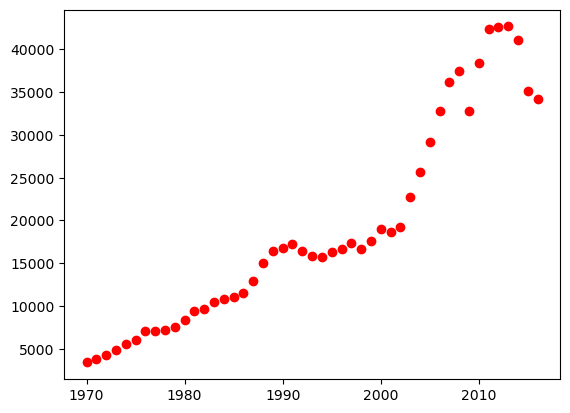

In [52]:
%matplotlib inline
plt.scatter(cd['year'], cd['per capita income (US$)'],color="red")

In [18]:
re=linear_model.LinearRegression()
re.fit(cd[['year']],cd['per capita income (US$)'])

LinearRegression()

In [19]:
re.predict([[2020]])

C:\Anaconda\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([41288.69409442])

# Multivariate Regression

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model


In [24]:
r=pd.read_csv("rooms.csv")
r

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


Pre-processing :Handling NA values

In [25]:
import math
median_bedrooms=math.floor(r['bedrooms'].median())
median_bedrooms

3

In [26]:
r['bedrooms']=r['bedrooms'].fillna(median_bedrooms)
r

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,3.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


In [27]:
reg=linear_model.LinearRegression()
reg.fit(r[['area','bedrooms','age']],r['price'])


LinearRegression()

In [28]:
reg.coef_

array([   137.25, -26025.  ,  -6825.  ])

In [29]:
reg.intercept_

383724.9999999998

In [30]:
reg.predict([[3000,3,40]])

C:\Anaconda\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([444400.])

### session2-home work


In [37]:
h=pd.read_csv("hiring.csv")
h


,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


pre processing data


In [38]:
import math
median_score=math.floor(h['test_score(out of 10)'].median())
median_score



8

In [39]:
h['test_score(out of 10)']=h['test_score(out of 10)'].fillna(median_score)
h['experience']=h['experience'].fillna("zero")
h

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,zero,8.0,9,50000
1,zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,8.0,7,72000
7,eleven,7.0,8,80000


In [40]:
pip install word2number


Note: you may need to restart the kernel to use updated packages.


In [41]:
h["experience"] = h.experience.astype(str)
h.experience = h.experience.apply(w2n.word_to_num)
h

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


In [42]:

reg=linear_model.LinearRegression()
reg.fit(h[["experience","test_score(out of 10)","interview_score(out of 10)"]],h['salary($)'])


LinearRegression()

In [43]:
reg.predict([[2,9,6]])

C:\Anaconda\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([53205.96797671])

In [44]:
reg.predict([[12,10,10]])

C:\Anaconda\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([92002.18340611])